In [1]:
!pip install -q "trl>=0.12" "peft>=0.12" "transformers>=4.45" datasets accelerate pandas matplotlib

In [2]:
import json, random, re, torch, pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig
from trl import DPOConfig, DPOTrainer

SEED = 42
random.seed(SEED); torch.manual_seed(SEED)

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"   # or "meta-llama/Llama-3.2-1B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cpu


In [3]:
raw = [
 # ---------- Computer science / AI ----------
 ("What is overfitting in machine learning?",
  "**Definition:** Overfitting happens when a model learns the training data too closely, including its noise, and performs poorly on new data.\n\n**Key points:**\n1. Training accuracy is high, but test accuracy is much lower.\n2. It is common with very complex models or small datasets.\n3. Fixes include more data, regularization, simpler models and cross-validation.\n\n**Example:** A student who memorises past exam answers but cannot solve new questions is 'overfitting' to the past papers.",
  "Overfitting is when the model is too good in a way that is bad. It kind of memorises things and so it does not really work later. There are ways to stop it, people usually do some things like that."),
 ("What is the difference between supervised and unsupervised learning?",
  "**Short answer:** Supervised learning uses labelled data; unsupervised learning finds patterns in unlabelled data.\n\n**Supervised:** inputs come with correct outputs (e.g. emails marked spam / not spam). Used for classification and regression.\n\n**Unsupervised:** no labels are given (e.g. customer data). The model groups or compresses the data, as in clustering.\n\n**Rule of thumb:** if you have the answers, it is supervised; if you are exploring, it is unsupervised.",
  "Supervised is when there is supervision and unsupervised is when there is not. Both are used in machine learning for different tasks depending on the situation and the data you have."),
 ("What is a binary search algorithm?",
  "**Definition:** Binary search finds an item in a *sorted* list by repeatedly halving the search range.\n\n**Steps:**\n1. Look at the middle element.\n2. If it equals the target, stop.\n3. If the target is smaller, search the left half; otherwise search the right half.\n4. Repeat until found or the range is empty.\n\n**Complexity:** O(log n), so 1,000,000 items need only about 20 comparisons.",
  "Binary search is a search method that uses binary. You go through the list and look for the thing, and it is faster than other searches because of how it works with the data."),
 ("What is a database index and why is it useful?",
  "**Definition:** An index is a separate data structure that lets a database find rows quickly without scanning the whole table.\n\n**Analogy:** It works like the index at the back of a textbook: you look up the topic and jump to the page.\n\n**Benefits:** much faster SELECT queries on the indexed column.\n**Trade-offs:** extra storage and slightly slower INSERT/UPDATE operations.",
  "An index is used in databases to make things faster. It is a structure that has pointers and B-tree or hash internals, which are optimised for lookups, and so queries are better when it exists."),
 ("What is the difference between a stack and a queue?",
  "Both store items in order, but they remove them differently.\n\n- **Stack:** Last In, First Out (LIFO). Example: a pile of plates; you take the top one. Operations: push, pop.\n- **Queue:** First In, First Out (FIFO). Example: a line at a ticket counter. Operations: enqueue, dequeue.\n\n**Uses:** stacks for undo features and function calls; queues for task scheduling and printing.",
  "A stack and a queue are both data structures. They are different from each other in some ways. One of them goes one way and the other goes the other way when you take things out."),
 ("What is normalization in databases?",
  "**Definition:** Normalization is organising tables so that each fact is stored only once, which reduces duplication and update errors.\n\n**Common forms:**\n1. **1NF** - each cell holds a single value.\n2. **2NF** - every non-key column depends on the whole primary key.\n3. **3NF** - non-key columns do not depend on other non-key columns.\n\n**Example:** Instead of repeating a customer's address on every order row, store it once in a Customers table and link by customer ID.",
  "Normalization is about making the database better by splitting tables up. There are normal forms like first, second and third and they have rules, so the data becomes more normal and clean."),
 # ---------- Mathematics / statistics ----------
 ("What is a derivative?",
  "**Definition:** The derivative of a function measures how fast its output changes as its input changes - the slope of the curve at a point.\n\n**Formula:** f'(x) = lim(h->0) [f(x+h) - f(x)] / h\n\n**Example:** If f(x) = x^2, then f'(x) = 2x. At x = 3 the slope is 6, so the function is rising 6 units for every 1 unit of x.\n\n**Use:** finding speeds, maximum/minimum values and optimising models.",
  "A derivative is a calculus thing that tells you about change. You take the limit of something and then you get another function. It is important in math and many fields use it."),
 ("What is the Central Limit Theorem?",
  "**Statement:** If you take many random samples of size n from any population and compute each sample's mean, the distribution of those means approaches a normal distribution as n grows (usually n >= 30 is enough).\n\n**Why it matters:**\n- It lets us use normal-distribution tools even when the data are not normal.\n- It underlies confidence intervals and hypothesis tests.\n\n**Example:** Individual die rolls are uniform, but the average of 30 rolls is approximately bell-shaped.",
  "The Central Limit Theorem says that things become normal when there are enough of them. It is a big result in statistics, and mathematicians proved it for convergence in distribution under some conditions."),
 ("What is the difference between mean, median and mode?",
  "All three describe the 'centre' of data:\n\n- **Mean:** sum of values divided by the count. Sensitive to outliers.\n- **Median:** the middle value when sorted. Robust to outliers.\n- **Mode:** the most frequent value.\n\n**Example:** For 2, 3, 3, 5, 12 -> mean = 5, median = 3, mode = 3. The outlier 12 pulls the mean up but not the median.",
  "Mean median and mode are averages. The mean is the average, the median is another kind, and the mode is also one. You should use whichever is best for your data."),
 ("What is a p-value?",
  "**Definition:** A p-value is the probability of seeing results at least as extreme as yours *if the null hypothesis were true*.\n\n**How to read it:**\n- Small p (commonly < 0.05): data are unlikely under the null, so we reject it.\n- Large p: the data are consistent with the null.\n\n**Common mistake:** it is *not* the probability that the null hypothesis is true.",
  "The p-value tells you if your result is significant. If it is small, then it is good and means something was found. Researchers like p-values because they give a number for the evidence."),
 ("What is a matrix determinant?",
  "**Definition:** The determinant is a single number computed from a square matrix that tells us how the matrix scales area (2x2) or volume (3x3).\n\n**2x2 formula:** for [[a, b], [c, d]], det = ad - bc.\n\n**Example:** [[2, 1], [4, 3]] -> det = 2*3 - 1*4 = 2.\n\n**Key fact:** det = 0 means the matrix is not invertible.",
  "The determinant is a value from a matrix. You do some multiplication and subtraction of the entries to get it. It is used in linear algebra for many things like inverses and so on."),
 # ---------- Physics ----------
 ("Explain Newton's second law of motion.",
  "**Statement:** The acceleration of an object is directly proportional to the net force on it and inversely proportional to its mass: **F = ma**.\n\n**Meaning:** a bigger force gives a bigger acceleration; a heavier object accelerates less for the same force.\n\n**Example:** Pushing an empty shopping cart is easy; pushing a full one with the same force gives a much smaller acceleration.\n\n**Units:** force in newtons (N), mass in kg, acceleration in m/s^2.",
  "Newton's second law is about force and motion. If you push something it moves, and how much it moves depends on things. Newton wrote it a long time ago and it is one of three laws."),
 ("What is the difference between speed and velocity?",
  "- **Speed** is a scalar: how fast an object moves (e.g. 60 km/h). It has magnitude only.\n- **Velocity** is a vector: speed *plus direction* (e.g. 60 km/h north).\n\n**Example:** A car going around a circular track at constant speed has changing velocity because its direction keeps changing.",
  "Speed and velocity are similar and people often mix them up. Velocity is more of a vector kind of thing while speed is simpler, but they both measure how things move."),
 ("What is Ohm's law?",
  "**Statement:** The current through a conductor is proportional to the voltage across it: **V = IR**.\n\n**Terms:** V = voltage (volts), I = current (amperes), R = resistance (ohms).\n\n**Example:** A 12 V battery across a 4-ohm resistor gives I = 12/4 = 3 A.\n\n**Note:** it applies to 'ohmic' materials where resistance stays constant.",
  "Ohm's law connects voltage, current and resistance in circuits. It is an equation and it is used a lot by electricians and engineers when they are working with electrical things."),
 # ---------- Biology / chemistry ----------
 ("What is photosynthesis?",
  "**Definition:** Photosynthesis is the process by which plants, algae and some bacteria convert light energy into chemical energy stored as glucose.\n\n**Equation:** 6CO2 + 6H2O + light -> C6H12O6 + 6O2\n\n**Two stages:**\n1. **Light reactions** (thylakoids): light splits water, releasing O2 and making ATP/NADPH.\n2. **Calvin cycle** (stroma): ATP/NADPH are used to fix CO2 into glucose.\n\n**Importance:** it produces the oxygen we breathe and the base of most food chains.",
  "Photosynthesis is how plants make food using the sun. It happens in the leaves with chlorophyll and there is a lot of chemistry, such as light dependent and independent steps that are complicated."),
 ("What is the difference between mitosis and meiosis?",
  "| Feature | Mitosis | Meiosis |\n|---|---|---|\n| Purpose | Growth and repair | Making gametes (sex cells) |\n| Divisions | 1 | 2 |\n| Daughter cells | 2, identical | 4, genetically different |\n| Chromosome number | Same as parent (diploid) | Halved (haploid) |\n\n**Key idea:** mitosis copies cells; meiosis shuffles and halves the genetic material to create variation.",
  "Mitosis and meiosis are both types of cell division. Mitosis is the normal one and meiosis is the other one that is in reproduction. They have phases like prophase and so on which are a bit different."),
 ("What is an acid and a base?",
  "**Acid:** a substance that releases hydrogen ions (H+) in water; pH below 7; tastes sour (e.g. lemon juice, HCl).\n**Base:** a substance that releases hydroxide ions (OH-) or accepts H+; pH above 7; feels slippery (e.g. soap, NaOH).\n\n**Neutral:** pH 7, such as pure water.\n**Reaction:** acid + base -> salt + water (neutralisation).",
  "Acids and bases are chemicals. Acids are on one side of the pH scale and bases are on the other. According to the Bronsted-Lowry and Lewis theories there are various definitions that apply in different situations."),
 ("What is DNA?",
  "**Definition:** DNA (deoxyribonucleic acid) is the molecule that stores an organism's genetic instructions.\n\n**Structure:** a double helix made of two strands of nucleotides. Each nucleotide has a sugar, a phosphate and one of four bases: A, T, C, G. A pairs with T, and C pairs with G.\n\n**Function:** the order of bases codes for proteins, and DNA is copied when cells divide so genetic information is passed on.",
  "DNA is in your cells and it is what makes you who you are. It has a shape that is a helix and scientists found it a long time ago. It carries information and genes and such."),
 # ---------- Economics / general ----------
 ("What is inflation?",
  "**Definition:** Inflation is a sustained rise in the general price level, so each unit of money buys less over time.\n\n**Measured by:** indices such as the Consumer Price Index (CPI).\n\n**Common causes:**\n- Demand-pull: too much demand for too few goods.\n- Cost-push: higher production costs (e.g. oil prices).\n\n**Example:** If inflation is 5%, something that cost Rs. 100 last year costs about Rs. 105 now.",
  "Inflation is when things get more expensive. The economy has a lot of factors and so prices go up, and central banks try to do things about it with policies that are sometimes effective."),
 ("What is supply and demand?",
  "**Demand:** as price falls, buyers want more (downward-sloping curve).\n**Supply:** as price rises, sellers offer more (upward-sloping curve).\n**Equilibrium:** the price where the quantity demanded equals the quantity supplied.\n\n**Example:** If a festival increases demand for flowers, prices rise until the market settles at a new equilibrium.",
  "Supply and demand is the most basic idea in economics. It is how markets work and the price is decided in some way by both things interacting with each other over time."),
 ("How should I structure an academic essay?",
  "A clear essay has three parts:\n\n1. **Introduction** - hook, brief context and a one-sentence thesis.\n2. **Body paragraphs** - each with one main idea: topic sentence, evidence, explanation, link back to the thesis.\n3. **Conclusion** - restate the thesis in new words, summarise key points, and end with a broader implication.\n\n**Tip:** write the thesis first, then outline one body paragraph per supporting argument.",
  "You should start with an introduction and then write what you want to say and then end it. Make sure it flows well and has good points and that the teacher will like it."),
 ("What is the scientific method?",
  "**Definition:** The scientific method is a systematic way of investigating questions using evidence.\n\n**Steps:**\n1. Observe and ask a question.\n2. Form a testable hypothesis.\n3. Run an experiment with controlled variables.\n4. Collect and analyse data.\n5. Conclude and share results so others can repeat them.\n\n**Key idea:** a hypothesis must be falsifiable - there must be a possible result that would prove it wrong.",
  "The scientific method is what scientists do. They think of things and test them and then they know. It has steps that you learn in school and it is very important for discoveries."),
 ("What is the time complexity of bubble sort?",
  "**Answer:** Bubble sort is O(n^2) in the average and worst cases, and O(n) in the best case (already sorted, with an early-exit check).\n\n**Why:** it makes up to n passes, and each pass compares up to n adjacent pairs, giving about n x n comparisons.\n\n**Space:** O(1), because it sorts in place.\n\n**Takeaway:** simple to understand, but too slow for large datasets; merge sort or quicksort are preferred.",
  "Bubble sort is slow. It is quadratic because of the loops, and that is why it is not used much in practice. There are better ones, and the complexity is something you can calculate."),
]

df = pd.DataFrame(raw, columns=["question", "chosen", "rejected"])
print(len(df), "preference pairs")
df.head(3)

23 preference pairs


,question,chosen,rejected
0,What is overfitting in machine learning?,**Definition:** Overfitting happens when a mod...,Overfitting is when the model is too good in a...
1,What is the difference between supervised and ...,**Short answer:** Supervised learning uses lab...,Supervised is when there is supervision and un...
2,What is a binary search algorithm?,**Definition:** Binary search finds an item in...,Binary search is a search method that uses bin...


In [4]:
SYSTEM = "You are a helpful tutor. Answer questions for undergraduate students."

def to_dpo_row(r):
    return {
        "prompt":   [{"role": "system", "content": SYSTEM},
                     {"role": "user", "content": r["question"]}],
        "chosen":   [{"role": "assistant", "content": r["chosen"]}],
        "rejected": [{"role": "assistant", "content": r["rejected"]}],
    }

dpo_ds = Dataset.from_list([to_dpo_row(r) for r in df.to_dict("records")]).shuffle(seed=SEED)
split = dpo_ds.train_test_split(test_size=0.15, seed=SEED)
train_ds, val_ds = split["train"], split["test"]
print(train_ds, val_ds, sep="\n")

# Save a plain-text copy of the dataset
df.rename(columns={"question": "prompt"}).to_json("academic_preference_dataset.jsonl", orient="records", lines=True, force_ascii=False)

Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 19
})
Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 4
})


In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32).to(device)

test_questions = [
    "What is gradient descent?",
    "Explain the difference between TCP and UDP.",
    "What is entropy in thermodynamics?",
    "What is a hash table?",
    "What is the law of supply in economics?",
]

def ask(model, question, max_new_tokens=220):
    msgs = [{"role": "system", "content": SYSTEM}, {"role": "user", "content": question}]
    text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    model.eval()
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                             repetition_penalty=1.1, pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

before = {q: ask(model, q) for q in test_questions}
for q, a in before.items():
    print("Q:", q, "\nA (BEFORE):", a, "\n" + "-"*80)

`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Q: What is gradient descent? 
A (BEFORE): Gradient descent is an optimization algorithm used to find the minimum of a function by iteratively moving in the direction of steepest descent, and decreasing the function's value at each step. It works by calculating the slope of the function at each point and then adjusting the parameters (usually weights or coefficients) of the model until convergence.

The basic idea behind gradient descent is that it takes the derivative of the loss function with respect to the parameters, which gives us the direction of steepest ascent. By taking the negative of this derivative, we can move in the opposite direction to minimize the loss function. This process continues until the change in the loss function is very small, indicating that the current set of parameters has reached the minimum.

In practice, gradient descent is often used as part of more complex algorithms like stochastic gradient descent, where multiple iterations of the same process are pe

In [6]:
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

peft_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

training_args = DPOConfig(
    output_dir="dpo_academic_qa",
    beta=0.1,
    learning_rate=5e-5,
    num_train_epochs=4,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    max_length=768,
    logging_steps=1,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none",
    bf16=use_bf16,
    fp16=(torch.cuda.is_available() and not use_bf16),
    seed=SEED,
)

trainer = DPOTrainer(
    model=model,
    ref_model=None,                 # adapter-disabled base model acts as reference
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    peft_config=peft_config,
)
trainer.train()

Tokenizing train dataset:   0%|          | 0/19 [00:00<?, ? examples/s]

Dropping fully truncated examples from train dataset:   0%|          | 0/19 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

Dropping fully truncated examples from eval dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
C:\Users\Hp\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
1,0.190700,0.186945,1.543506,3878.000000,-0.725330,-0.398449,0.574627,0.478075,-1.293239,1.000000,1.771314,-170.871658,-127.660286
2,0.021000,0.070593,1.419401,7756.000000,-0.979778,-0.764428,0.569652,0.399076,-2.967812,1.000000,3.366888,-171.661652,-144.406021
3,0.001500,0.039202,1.348112,11634.000000,-1.132372,-1.000184,0.572139,0.325183,-4.020568,1.000000,4.345750,-172.400574,-154.933578
4,0.002200,0.031635,1.327443,15512.000000,-1.178195,-1.075838,0.577114,0.305129,-4.376956,1.000000,4.682084,-172.601120,-158.497452


TrainOutput(global_step=12, training_loss=0.12192636247588477, metrics={'train_runtime': 1608.8516, 'train_samples_per_second': 0.047, 'train_steps_per_second': 0.007, 'total_flos': 46084926712320.0, 'train_loss': 0.12192636247588477, 'epoch': 4.0})

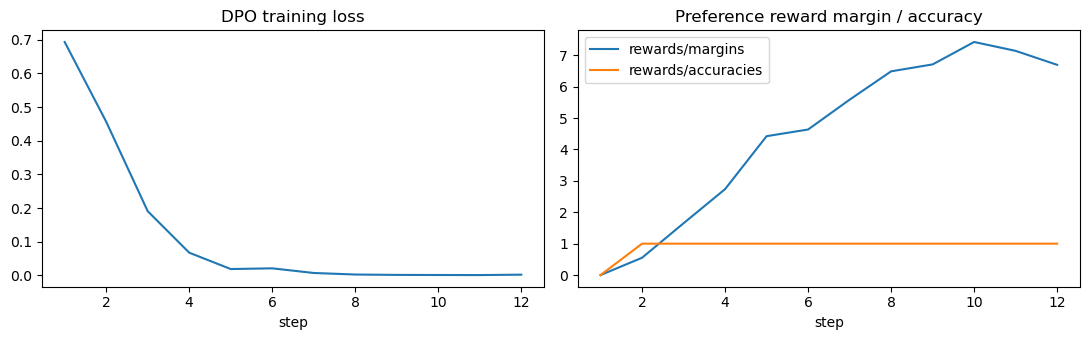

In [7]:
# Training curves: loss and reward margin (chosen reward - rejected reward)
logs = pd.DataFrame(trainer.state.log_history)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
if "loss" in logs:
    logs.dropna(subset=["loss"]).plot(x="step", y="loss", ax=ax[0], title="DPO training loss", legend=False)
for col in ["rewards/margins", "rewards/accuracies"]:
    if col in logs:
        logs.dropna(subset=[col]).plot(x="step", y=col, ax=ax[1], label=col)
ax[1].set_title("Preference reward margin / accuracy")
plt.tight_layout(); plt.show()

In [8]:
dpo_model = trainer.model
after = {q: ask(dpo_model, q) for q in test_questions}
for q, a in after.items():
    print("Q:", q, "\nA (AFTER):", a, "\n" + "-"*80)

Q: What is gradient descent? 
A (AFTER): Gradient descent is an iterative optimization algorithm used to find the minimum of a function by iteratively moving in the direction of steepest descent of the function's value, while minimizing its cost or loss. The process involves:

1. **Initialization**: Start with an initial guess (often called the "initial estimate") for the optimal solution.

2. **Compute Gradient**: Calculate the derivative of the function at the current point. This gives you the slope of the function at that point.

3. **Update Parameter**: Move towards the direction of the steepest descent by adjusting the parameter(s) in the opposite direction of the gradient.

4. **Repeat**: Repeat steps 2 and 3 until convergence criteria are met (e.g., a certain number of iterations, change in the parameter being less than a threshold).

The update rule for each iteration is typically:
\[ \mathbf{w} = \mathbf{w} - \alpha \nabla f(\mathbf{w}) \]
where:
- \( \mathbf{w} \) is the vect

In [9]:
for q in test_questions:
    print("="*100); print("QUESTION:", q)
    print("\n--- BEFORE DPO ---\n" + before[q])
    print("\n--- AFTER DPO ----\n" + after[q])

QUESTION: What is gradient descent?

--- BEFORE DPO ---
Gradient descent is an optimization algorithm used to find the minimum of a function by iteratively moving in the direction of steepest descent, and decreasing the function's value at each step. It works by calculating the slope of the function at each point and then adjusting the parameters (usually weights or coefficients) of the model until convergence.

The basic idea behind gradient descent is that it takes the derivative of the loss function with respect to the parameters, which gives us the direction of steepest ascent. By taking the negative of this derivative, we can move in the opposite direction to minimize the loss function. This process continues until the change in the loss function is very small, indicating that the current set of parameters has reached the minimum.

In practice, gradient descent is often used as part of more complex algorithms like stochastic gradient descent, where multiple iterations of the same 

In [10]:
# Simple, transparent style metrics (heuristic - supplement with your own reading!)
def metrics(text):
    words = re.findall(r"\w+", text)
    sents = [s for s in re.split(r"[.!?]+\s", text) if s.strip()]
    return {
        "words": len(words),
        "avg_sentence_len": round(len(words) / max(1, len(sents)), 1),
        "list_items": len(re.findall(r"^\s*(?:[-*]|\d+[.)])\s", text, flags=re.M)),
        "bold_headings": len(re.findall(r"\*\*[^*]+\*\*", text)),
        "has_example": int(bool(re.search(r"\bexample|e\.g\.|for instance|analogy", text, re.I))),
        "has_definition": int(bool(re.search(r"definition|is (?:a|an|the) ", text[:200], re.I))),
    }

rows = []
for q in test_questions:
    rows.append({"question": q, "model": "before", **metrics(before[q])})
    rows.append({"question": q, "model": "after",  **metrics(after[q])})
res = pd.DataFrame(rows)
summary = res.groupby("model").mean(numeric_only=True).round(2).loc[["before", "after"]]
summary

,words,avg_sentence_len,list_items,bold_headings,has_example,has_definition
model,,,,,,
before,169.8,19.82,2.6,1.8,0.0,0.6
after,164.6,15.42,6.2,4.6,0.6,0.6


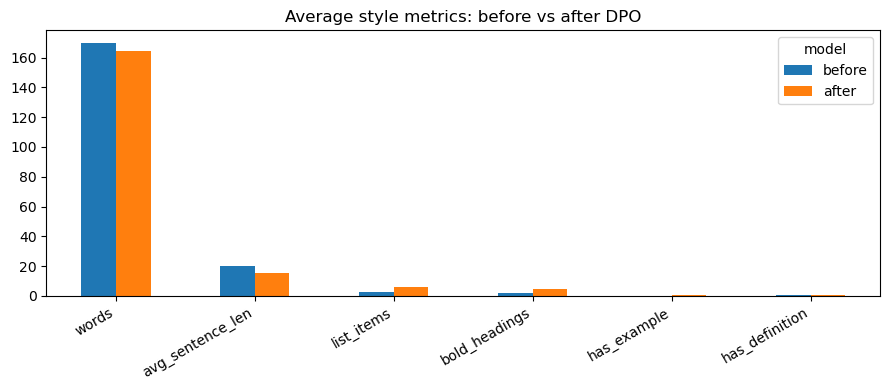

In [11]:
summary.T.plot(kind="bar", figsize=(9, 4), title="Average style metrics: before vs after DPO")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

In [12]:
trainer.model.save_pretrained("dpo_academic_adapter")
tokenizer.save_pretrained("dpo_academic_adapter")

# Optional: merge LoRA into the base model for export (e.g. to GGUF / Ollama)
# merged = trainer.model.merge_and_unload()
# merged.save_pretrained("dpo_academic_merged"); tokenizer.save_pretrained("dpo_academic_merged")

# Save before/after answers for your report
pd.DataFrame({"question": test_questions,
              "before_dpo": [before[q] for q in test_questions],
              "after_dpo":  [after[q] for q in test_questions]}).to_csv("before_after_comparison.csv", index=False)